In [1]:
import pandas as pd
import numpy as np

In [2]:
work=pd.read_json("train.json")

In [3]:
work.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        25000 non-null  float64
 1   bedrooms         25000 non-null  int64  
 2   building_id      25000 non-null  str    
 3   created          25000 non-null  str    
 4   description      25000 non-null  str    
 5   display_address  25000 non-null  str    
 6   features         25000 non-null  object 
 7   interest_level   25000 non-null  str    
 8   latitude         25000 non-null  float64
 9   listing_id       25000 non-null  int64  
 10  longitude        25000 non-null  float64
 11  manager_id       25000 non-null  str    
 12  photos           25000 non-null  object 
 13  price            25000 non-null  int64  
 14  street_address   25000 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 2.9+ MB


In [5]:
def safe_list_length(value):
    if isinstance(value, (list, tuple)):
        return len(value)
    return 0

work["feature_count"] = work["features"].apply(safe_list_length)
work["photo_count"] = work["photos"].apply(safe_list_length)

work["created"] = pd.to_datetime(work["created"], errors="coerce")
work["listing_hour"] = work["created"].dt.hour
work["listing_dayofweek"] = work["created"].dt.dayofweek

display(
    work[
        ["bedrooms", "bathrooms", "price", 
         "feature_count", "photo_count", "listing_hour", 
         "listing_dayofweek", "interest_level"]
    ].head()
)
display(
    work[
        ["bedrooms", "bathrooms", "price", 
         "feature_count", "photo_count", "listing_hour", 
         "listing_dayofweek", "interest_level"]
    ].head().shape
)
work.shape

,bedrooms,bathrooms,price,feature_count,photo_count,listing_hour,listing_dayofweek,interest_level
0,2,1.0,3487,1,3,13,2,medium
1,0,1.0,2843,4,4,8,5,low
2,1,1.0,2653,5,4,9,4,high
3,1,2.5,2484,4,5,20,6,low
4,1,2.5,2896,5,4,10,0,medium


(5, 8)

(25000, 19)

In [6]:
work.describe()

,bathrooms,bedrooms,created,latitude,listing_id,longitude,price,feature_count,photo_count,listing_hour,listing_dayofweek
count,25000.00000,25000.000000,25000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,1.60728,1.185760,2016-05-31 12:37:12.290400,40.736858,6.812500e+06,-73.971151,3974.746200,4.019680,4.983480,11.565600,3.019040
min,1.00000,0.000000,2016-04-01 00:00:00,40.658720,6.800000e+06,-74.020673,1300.000000,0.000000,0.000000,0.000000,0.000000
25%,1.00000,0.000000,2016-05-01 01:17:15,40.712646,6.806250e+06,-73.995791,2701.000000,3.000000,3.000000,6.000000,1.000000
50%,1.50000,1.000000,2016-05-31 14:25:00,40.733418,6.812500e+06,-73.977007,3640.000000,4.000000,5.000000,12.000000,3.000000
75%,2.00000,2.000000,2016-07-01 02:50:30,40.759844,6.818749e+06,-73.951322,4866.000000,5.000000,6.000000,18.000000,5.000000
max,3.00000,4.000000,2016-07-30 23:45:00,40.822954,6.824999e+06,-73.903218,18000.000000,12.000000,16.000000,23.000000,6.000000
std,0.68493,1.056947,NaN,0.035651,7.217023e+03,0.027599,1741.916393,2.011332,2.232534,6.939979,1.989783


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_demo=TfidfVectorizer(
    stop_words="english",
    max_features=20
)

features=work["features"].fillna("").astype(str)
features_to_data=tfidf_demo.fit_transform(features)
print("TF-IDF matrix shape:",features_to_data.shape)
print("Example vocabulary:")
print(list(tfidf_demo.get_feature_names_out()))

TF-IDF matrix shape: (25000, 20)
Example vocabulary:
['allowed', 'cats', 'center', 'concierge', 'dishwasher', 'dogs', 'doorman', 'elevator', 'fee', 'floors', 'hardwood', 'high', 'internet', 'laundry', 'outdoor', 'pool', 'space', 'speed', 'swimming', 'unit']


In [8]:
def safe_list_length(value):
    if isinstance(value, (list, tuple)):
        return len(value)
    return 0

def features_to_text(value):
    if isinstance(value, list):
        return " ".join(str(item) for item in value)
    return ""

work["feature_count"] = work["features"].apply(safe_list_length)
work["photo_count"] = work["photos"].apply(safe_list_length)

work["features_to_text"] = work["features"].apply(features_to_text)

display(
    work[
        ["features", "features_to_text", "feature_count", 
         "photos", "photo_count"]
    ].head()
)

,features,features_to_text,feature_count,photos,photo_count
0,[Outdoor Space],Outdoor Space,1,"[https://img.example.com/0_0.jpg, https://img....",3
1,"[Roof Deck, Outdoor Space, Concierge, Cats All...",Roof Deck Outdoor Space Concierge Cats Allowed,4,"[https://img.example.com/1_0.jpg, https://img....",4
2,"[No Fee, Common Outdoor Space, Pre-War, Hardwo...",No Fee Common Outdoor Space Pre-War Hardwood F...,5,"[https://img.example.com/2_0.jpg, https://img....",4
3,"[Outdoor Space, Cats Allowed, Laundry in Unit,...",Outdoor Space Cats Allowed Laundry in Unit Roo...,4,"[https://img.example.com/3_0.jpg, https://img....",5
4,"[Laundry in Building, Elevator, Common Outdoor...",Laundry in Building Elevator Common Outdoor Sp...,5,"[https://img.example.com/4_0.jpg, https://img....",4


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_preprocessor=Pipeline([
    ("Imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])
print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [10]:
numeric_features = [
    'bathrooms',
    'bedrooms',
    'latitude',
    'longitude',
    'price',
    'feature_count',
    'photo_count'
]

text_features = [
    'description',
    'features_to_text'
]

text_preprocessor=TfidfVectorizer(
    stop_words="english",
    max_features=1000,
    ngram_range=(1,2)
)

from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_preprocessor, numeric_features),
        ("text_desc", text_preprocessor, 'description'),
        ("text_feats", TfidfVectorizer(stop_words='english', max_features=100), 'features_to_text')
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(work)
print("feature matrix shape:", X_processed.shape)

feature matrix shape: (25000, 472)


In [11]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

X = work[numeric_features +text_features].copy()
y = work['interest_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)

logistic_tfidf = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_tfidf.fit(X_train, y_train)
tfidf_pred = logistic_tfidf.predict(X_test)

print("TF-IDF + Logistic Regression trained successfully!")
print("Accuracy:", round(accuracy_score(y_test, tfidf_pred), 3))
print("Macro F1:", round(f1_score(y_test, tfidf_pred, average="macro"), 3))

TF-IDF + Logistic Regression trained successfully!
Accuracy: 0.582
Macro F1: 0.417


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

rf_basic = Pipeline([
    ("preprocessing", numeric_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

rf_basic.fit(X_train_num, y_train)
rf_pred = rf_basic.predict(X_test_num)

rf_tfidf = Pipeline([
    ("preprocessing",preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])

rf_tfidf.fit(X_train, y_train)
tfidf_pred = rf_tfidf.predict(X_test)
print("=== Model 1: Random Forest (Numeric Features Only) ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 3))
print("Macro F1:", round(f1_score(y_test, rf_pred, average="macro"), 3))

print("\n=== Model 2: Random Forest (Numeric + TF-IDF Text) ===")
print("Accuracy:", round(accuracy_score(y_test, tfidf_pred), 3))
print("Macro F1:", round(f1_score(y_test, tfidf_pred, average="macro"), 3))

=== Model 1: Random Forest (Numeric Features Only) ===
Accuracy: 0.57
Macro F1: 0.414

=== Model 2: Random Forest (Numeric + TF-IDF Text) ===
Accuracy: 0.583
Macro F1: 0.388


In [13]:
from sklearn.dummy import DummyClassifier
dummy=DummyClassifier(strategy="most_frequent")
dummy.fit(X_train,y_train)
dummy_pred=dummy.predict(X_test)
print(
    "Majority Baseline Accuracy",
    round(accuracy_score(y_test,dummy_pred),4)
)
print(
    "Majority Baseline Macro F1:",
    round(f1_score(
        y_test,
        dummy_pred,
        average="macro"
    ),4)
)

Majority Baseline Accuracy 0.5426
Majority Baseline Macro F1: 0.2345


In [14]:
from sklearn.metrics import classification_report
balanced_logistic=Pipeline([
    ('preprocessor',preprocessor),
    ("classifier",LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000
    ))
])
balanced_logistic.fit(X_train,y_train)
balanced_pred=balanced_logistic.predict(X_test)
print(
    "Balanced Accuracy:",
    round(accuracy_score(y_test,balanced_pred),4)
)
print(
    "Balanced Macro F1:",
    round(f1_score(
        y_test,
        balanced_pred,
        average="macro"
    ),4)
)
print(classification_report(
    y_test,
    balanced_pred
))

Balanced Accuracy: 0.4778
Balanced Macro F1: 0.4192
              precision    recall  f1-score   support

        high       0.21      0.57      0.30       549
         low       0.70      0.60      0.65      2713
      medium       0.38      0.26      0.31      1738

    accuracy                           0.48      5000
   macro avg       0.43      0.47      0.42      5000
weighted avg       0.54      0.48      0.49      5000



In [15]:
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(
    balanced_logistic,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
print("Fold Macro F1 scores:")
print(cv_scores)

print("\nMean:",
     round(cv_scores.mean(),4)
     )
print("Standard deviation:",
     round(cv_scores.std(),4))

Fold Macro F1 scores:
[0.45228606 0.42789189 0.43387799 0.44059906 0.42735926]

Mean: 0.4364
Standard deviation: 0.0093


In [16]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "classifier__C":[
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "classifier__class_weight":[
        None,
        "balanced"
    ]
}
grid_search=GridSearchCV(
    estimator=logistic_tfidf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train,y_train)
print("Best parameters:")
print(grid_search.best_params_)
print(
    "\nBest CV Macro F1:",
    round(grid_search.best_score_,4)
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters:
{'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

Best CV Macro F1: 0.4407


In [17]:
grid_pred=grid_search.best_estimator_.predict(X_test)
grid_accuracy=accuracy_score(
    y_test,
    grid_pred,
)
grid_macro_f1=f1_score(
    y_test,
    grid_pred,
    average="macro"
)
print(
    "GridSearch test accuracy:",
    round(grid_accuracy,4)
)
print(
    "GridSearch test Macro f1:",
    round(grid_macro_f1,4)
)
print(
    "\nClassification Report:"
)
print(classification_report(
    y_test,
    grid_pred
))

GridSearch test accuracy: 0.4898
GridSearch test Macro f1: 0.4285

Classification Report:
              precision    recall  f1-score   support

        high       0.22      0.61      0.32       549
         low       0.71      0.62      0.66      2713
      medium       0.40      0.25      0.30      1738

    accuracy                           0.49      5000
   macro avg       0.44      0.49      0.43      5000
weighted avg       0.55      0.49      0.50      5000



In [18]:
grid_results=pd.DataFrame(
    grid_search.cv_results_
)
display(
    grid_results[
        [
            "param_classifier__C",
            "param_classifier__class_weight",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ].sort_values("rank_test_score").head(10)
)

,param_classifier__C,param_classifier__class_weight,mean_test_score,std_test_score,rank_test_score
3,0.10,balanced,0.440654,0.005885,1
5,1.00,balanced,0.436403,0.009279,2
1,0.01,balanced,0.435585,0.004261,3
7,10.00,balanced,0.433459,0.010286,4
9,100.00,balanced,0.432333,0.010815,5
8,100.00,NaN,0.413781,0.008845,6
6,10.00,NaN,0.412530,0.008609,7
4,1.00,NaN,0.408896,0.007460,8
2,0.10,NaN,0.394686,0.004046,9
0,0.01,NaN,0.373661,0.003525,10


In [19]:
from sklearn.model_selection import RandomizedSearchCV
param_distributions={
    "classifier__C":[
        0.01,
        0.1,
        1,
        10,
        100
    ],
    "classifier__class_weight":[
        None,
        "balanced"
    ]
}
random_search=RandomizedSearchCV(
    estimator=logistic_tfidf,
    param_distributions=param_distributions,
    n_iter=8,
    cv=5,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train,y_train)
print("Best parameters")
print(random_search.best_params_)
print(
    "\nBest CV Macro F1:",
    round(random_search.best_score_,4)
     )

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters
{'classifier__class_weight': 'balanced', 'classifier__C': 1}

Best CV Macro F1: 0.4364


In [19]:
random_pred=random_search.best_estimator_.predict(X_test)
random_accuracy=accuracy_score(
    y_test,
    random_pred
)
random_macro_f1=f1_score(
    y_test,
    random_pred,
    average="macro"
)
print(
    "RandomizedSearch Test Accuracy:",
    round(random_accuracy,4)
)
print(
    "RandomizedSearch test Macro F1:",
    round(random_macro_f1,4)
)
print("\nClassification Report:")
print(classification_report(
    y_test,
    random_pred
))

RandomizedSearch Test Accuracy: 0.4778
RandomizedSearch test Macro F1: 0.4192

Classification Report:
              precision    recall  f1-score   support

        high       0.21      0.57      0.30       549
         low       0.70      0.60      0.65      2713
      medium       0.38      0.26      0.31      1738

    accuracy                           0.48      5000
   macro avg       0.43      0.47      0.42      5000
weighted avg       0.54      0.48      0.49      5000



In [20]:
from sklearn.compose import ColumnTransformer
rf_preprocessor=ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",SimpleImputer(
                        strategy="median"
                    )
                )
            ]),
            numeric_features
        ),
    ],
    remainder="drop"
)
rf_pipeline=Pipeline([
    ("preprocessor",rf_preprocessor),
    ("classifier",RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ))
])
rf_pipeline.fit(X_train,y_train)
rf_pred=rf_pipeline.predict(X_test)
print(
    "Random Froest Accuracy:",
    round(accuracy_score(y_test,rf_pred),4)
)
print(
    "Random Forest Macro F1:",
    round(f1_score(
        y_test,
        rf_pred,
        average="macro"
    ),4)
)

Random Froest Accuracy: 0.5676
Random Forest Macro F1: 0.4123


In [21]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200], 
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__class_weight": [None, "balanced"]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)
print(
    "\nBest RF CV Macro F1:",
    round(rf_grid.best_score_, 4)
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Random Forest parameters:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Best RF CV Macro F1: 0.4539


In [22]:
rf_tuned_pred=rf_grid.best_estimator_.predict(X_test)
rf_tuned_accuracy=accuracy_score(y_test,rf_tuned_pred)
rf_tuned_macro_f1=f1_score(y_test,rf_tuned_pred,average="macro")
print(
    "Tuned RF Accuracy:",
    round(rf_tuned_accuracy,4)
)
print(
    "Tuned RF Macro F1:",
    round(rf_tuned_macro_f1,4)
)
print("\nClassification Report:")
print(
    classification_report(
        y_test,rf_tuned_pred
    )
)

Tuned RF Accuracy: 0.503
Tuned RF Macro F1: 0.4582

Classification Report:
              precision    recall  f1-score   support

        high       0.24      0.55      0.33       549
         low       0.73      0.56      0.64      2713
      medium       0.41      0.39      0.40      1738

    accuracy                           0.50      5000
   macro avg       0.46      0.50      0.46      5000
weighted avg       0.57      0.50      0.52      5000



In [23]:
# Calculate the baseline Logistic Regression predictions
baseline_pred = logistic_tfidf.predict(X_test) # Use x_test_c if you are still using combined variables

# Create the missing variables the table is looking for
baseline_accuracy = accuracy_score(y_test, baseline_pred) # Use y_test_c if needed
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Balanced Logistic Regression",
        "GridSearch Logistic Regression",
        "RandomizedSearch Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, dummy_pred),
        baseline_accuracy,
        accuracy_score(y_test, balanced_pred),
        grid_accuracy,
        random_accuracy,
        accuracy_score(y_test, rf_pred),
        rf_tuned_accuracy
    ],
    "Macro_F1": [
        f1_score(y_test, dummy_pred, average="macro"), 
        baseline_macro_f1,
        f1_score(y_test, balanced_pred, average="macro"),
        grid_macro_f1,
        random_macro_f1,
        f1_score(y_test, rf_pred, average="macro"),
        rf_tuned_macro_f1
    ]
})

display(
    results.sort_values(
        "Macro_F1", 
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Macro_F1
0,Tuned Random Forest,0.5030,0.458157
1,GridSearch Logistic Regression,0.4898,0.428522
2,Balanced Logistic Regression,0.4778,0.419239
3,RandomizedSearch Logistic Regression,0.4778,0.419239
4,Logistic Regression,0.5816,0.416806
5,Random Forest,0.5676,0.412270
6,Majority Baseline,0.5426,0.234496


In [30]:
final_model=grid_search.best_estimator_
final_pred=final_model.predict(X_test)
print("Final Accuracy:",round(accuracy_score(y_test,final_pred),4))
print("Final Macro F1 :",round(f1_score(y_test,final_pred,average="macro"),4))
print("\nFinal Classification Report:")
print(classification_report(y_test,final_pred))

Final Accuracy: 0.4898
Final Macro F1 : 0.4285

Final Classification Report:
              precision    recall  f1-score   support

        high       0.22      0.61      0.32       549
         low       0.71      0.62      0.66      2713
      medium       0.40      0.25      0.30      1738

    accuracy                           0.49      5000
   macro avg       0.44      0.49      0.43      5000
weighted avg       0.55      0.49      0.50      5000



In [31]:
pip install shap lime    

Note: you may need to restart the kernel to use updated packages.


In [32]:
try:
    import shap
    
    shap_features = numeric_features
    X_shap = work[shap_features].copy()
    y_shap = work["interest_level"].copy()
    
    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        X_shap,
        y_shap,
        test_size=0.20,
        random_state=42,
        stratify=y_shap
    )
    
    shap_imputer = SimpleImputer(strategy="median")
    Xs_train_imp = shap_imputer.fit_transform(Xs_train)
    Xs_test_imp = shap_imputer.transform(Xs_test)
    
    shap_rf = RandomForestClassifier(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    )
    shap_rf.fit(Xs_train_imp, ys_train)
    
    shap_explainer = shap.TreeExplainer(shap_rf)
    
    # REDUCTION 1: Take a sample of 300 instances from the test set
    Xs_test_sample = shap.sample(Xs_test_imp, 300)
    
    # REDUCTION 2 & 3: Use approximate=True and check_additivity=False
    shap_values = shap_explainer.shap_values(
        Xs_test_sample,
        approximate=True,
        check_additivity=False
    )
    
    print("SHAP calculation completed.")
except Exception as e:
    print("SHAP could not run:", e)

SHAP calculation completed.


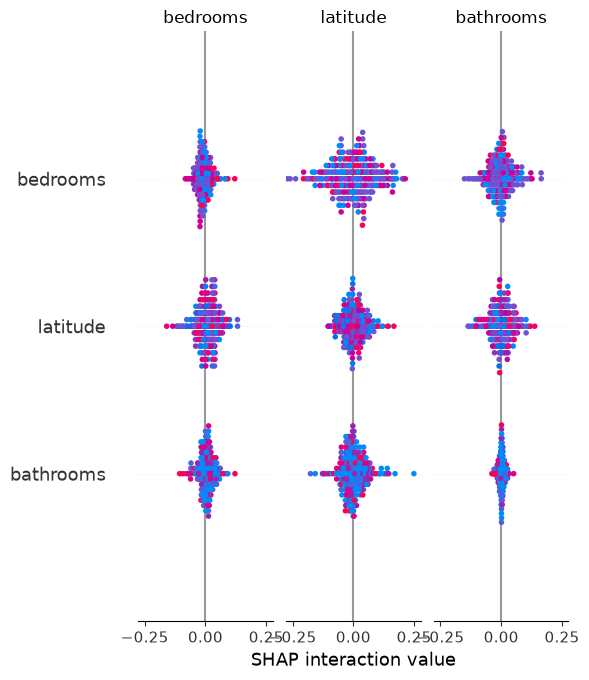

In [33]:
try:
    shap.summary_plot(
        shap_values,
        Xs_test_sample,               # CHANGED: Must match the data passed to shap_values
        feature_names=shap_features,  # CHANGED: Fixed the typo (removed 's')
        show=True
    )
except Exception as e:
    print("SHAP plotting format may differ in this SHAP version.")
    print("Error:", e)

In [34]:
try:
    from lime.lime_tabular import LimeTabularExplainer
    lime_explainer=LimeTabularExplainer(
        Xs_train_imp,
        feature_names=shap_features,
        class_names=sorted(y.unique()),
        mode="classification",
        random_state=42
    )
    lime_exp=lime_explainer.explain_instance(
        Xs_test_imp[0],
        shap_rf.predict_proba,
        num_features=8
    )
    for feature ,weight in lime_exp.as_list():
        print(f"{feature}:{weight:4f}")
except Exception as e:
    print("LIME could not run:",e)

price > 4877.25:0.148979
photo_count <= 3.00:0.122548
4.00 < feature_count <= 5.00:-0.117844
bathrooms > 2.00:-0.011480
1.00 < bedrooms <= 2.00:-0.007768
40.71 < latitude <= 40.73:0.005328
-74.00 < longitude <= -73.98:-0.002553


In [35]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [38]:
import joblib
joblib.dump(
    final_model,
    "first_model.joblib"
)
print("Model saved to:")
print("first_model.joblib")

Model saved to:
first_model.joblib


In [39]:
loaded_model = joblib.load("first_model.joblib")

In [40]:
test_predictions=loaded_model.predict(
    X_test.head(5)
)
print("Predictions from reloaded model:")
print(test_predictions)

Predictions from reloaded model:
['high' 'low' 'medium' 'high' 'low']


In [41]:
work.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   bathrooms          25000 non-null  float64       
 1   bedrooms           25000 non-null  int64         
 2   building_id        25000 non-null  str           
 3   created            25000 non-null  datetime64[us]
 4   description        25000 non-null  str           
 5   display_address    25000 non-null  str           
 6   features           25000 non-null  object        
 7   interest_level     25000 non-null  str           
 8   latitude           25000 non-null  float64       
 9   listing_id         25000 non-null  int64         
 10  longitude          25000 non-null  float64       
 11  manager_id         25000 non-null  str           
 12  photos             25000 non-null  object        
 13  price              25000 non-null  int64         
 14  street_address   

In [48]:
new_listing=pd.DataFrame({
    "price":[2500],
    "bedrooms":[1],
    "bathrooms":[1],
    "latitude":[40.75],
    "longitude":[-73.98],
    "feature_count":[5],
    "photo_count":[6],
    "listing_hour":[12],
    "listing_dayofweek":[2],

    "description":[
        "Beautiful apartment with large windows"
    ],
    "features_to_text":[
        "Doorman Elevator Hardwood Floors Laundry"
    ]
})
prediction=loaded_model.predict(
    new_listing
)
print(
    "Predicted interest level:",
    prediction[0]
)

Predicted interest level: high
